# TNG Group Catalog : EDA Subhalo Catalogs TNG300 vs. TNG50

## Import Basic Libraries

In [1]:
import numpy as np
import pandas as pd
import glob
import sys
import h5py
#from netCDF4 import Dataset
from datetime import datetime
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

import pyarrow as pa
import pyarrow.parquet as pq

from functools import reduce
import operator
import gc

In [2]:
# plot settings
plt.rc('font', family='serif') 
#plt.rc('font', serif='Times New Roman') 
plt.rcParams.update({'font.size': 16})
plt.rcParams['mathtext.fontset'] = 'stix'

## Define SparkSession and sparkContext

In [3]:
# PySpark packages
from pyspark import SparkContext   
from pyspark.sql import SparkSession

import pyspark.sql.functions as F
import pyspark.sql.types as T
from pyspark import Row
from pyspark.sql.window import Window as W


spark = SparkSession.builder \
    .master("yarn") \
    .appName("spark-shell") \
    .config("spark.driver.maxResultSize", "32g") \
    .config("spark.driver.memory", "32g") \
    .config("spark.executor.memory", "7g") \
    .config("spark.executor.cores", "1") \
    .config("spark.executor.instances", "150") \
    .getOrCreate()


sc = spark.sparkContext
sc.setCheckpointDir("hdfs://spark00:54310/tmp/checkpoints")

spark.conf.set("spark.sql.debug.maxToStringFields", 500)
spark.conf.set("spark.sql.execution.arrow.pyspark.enabled", "true")

In [4]:
sc.getConf().getAll()[:10]

[('spark.driver.memory', '32g'),
 ('spark.app.id', 'application_1740026882285_0047'),
 ('spark.org.apache.hadoop.yarn.server.webproxy.amfilter.AmIpFilter.param.PROXY_HOSTS',
  'spark17'),
 ('spark.driver.maxResultSize', '32g'),
 ('spark.master', 'yarn'),
 ('spark.org.apache.hadoop.yarn.server.webproxy.amfilter.AmIpFilter.param.PROXY_URI_BASES',
  'http://spark17:8088/proxy/application_1740026882285_0047'),
 ('spark.executor.id', 'driver'),
 ('spark.sql.warehouse.dir',
  'file:/home/shong/work/illustris/notebook/spark-warehouse'),
 ('spark.app.submitTime', '1742357636510'),
 ('spark.driver.appUIAddress', 'http://spark00:4041')]

## Read All Subhalo Parquet Files

- About IllustrisTNG, https://www.illustris-project.org/data/docs/specifications/
- About TNG300, https://www.tng-project.org/data/downloads/TNG300-1/

In [5]:
datapath = "hdfs://spark00:54310/common/data/illustris/tng300/snapshot99/groupcat/"

In [6]:
outpath = "hdfs://spark00:54310/common/data/illustris/tng300/snapshot99/reduced/"

In [7]:
%%time
# Read all parquets in the directory
rawdf = spark.read.option("header","true").option("recursiveFileLookup","true").parquet(datapath)

CPU times: user 2 ms, sys: 0 ns, total: 2 ms
Wall time: 3.24 s


In [8]:
rawdf.printSchema()

root
 |-- SubhaloBHMass: float (nullable = true)
 |-- SubhaloBHMdot: float (nullable = true)
 |-- SubhaloBfldDisk: float (nullable = true)
 |-- SubhaloBfldHalo: float (nullable = true)
 |-- SubhaloCM: array (nullable = true)
 |    |-- element: float (containsNull = true)
 |-- SubhaloFlag: boolean (nullable = true)
 |-- SubhaloGasMetalFractions: array (nullable = true)
 |    |-- element: float (containsNull = true)
 |-- SubhaloGasMetalFractionsHalfRad: array (nullable = true)
 |    |-- element: float (containsNull = true)
 |-- SubhaloGasMetalFractionsMaxRad: array (nullable = true)
 |    |-- element: float (containsNull = true)
 |-- SubhaloGasMetalFractionsSfr: array (nullable = true)
 |    |-- element: float (containsNull = true)
 |-- SubhaloGasMetalFractionsSfrWeighted: array (nullable = true)
 |    |-- element: float (containsNull = true)
 |-- SubhaloGasMetallicity: float (nullable = true)
 |-- SubhaloGasMetallicityHalfRad: float (nullable = true)
 |-- SubhaloGasMetallicityMaxRad: fl

## Mass Function

In [9]:
%%time
rawdf.select(['SubhaloMass']).describe().show()

+-------+-----------------+
|summary|      SubhaloMass|
+-------+-----------------+
|  count|         14485709|
|   mean|2.316779120800043|
| stddev|98.33343367327917|
|    min|      0.006456322|
|    max|         128334.6|
+-------+-----------------+

CPU times: user 1.97 ms, sys: 2.51 ms, total: 4.48 ms
Wall time: 21.6 s


> Total number of subhalos is `14,485,709`

#### Plot the histogram of `SubhaloMass`

In [10]:
%%time
# Step 1: Convert 'SubhaloMass' to Pandas
subhalo_mass = rawdf.select("SubhaloMass").toPandas()["SubhaloMass"]

CPU times: user 62 ms, sys: 73.1 ms, total: 135 ms
Wall time: 10.4 s


In [89]:
# Step 2: Define Log-Spaced Bins
num_bins = 50  # Adjust as needed
#log_bins = np.logspace(np.log10(subhalo_mass.min()), np.log10(subhalo_mass.max()), num_bins)
log_bins = np.logspace(np.log10(0.01), np.log10(1e5), num_bins)

In [90]:
# plot settings
plt.rc('font', family='serif') 
#plt.rc('font', serif='Times New Roman') 
plt.rcParams.update({'font.size': 16})
plt.rcParams['mathtext.fontset'] = 'stix'

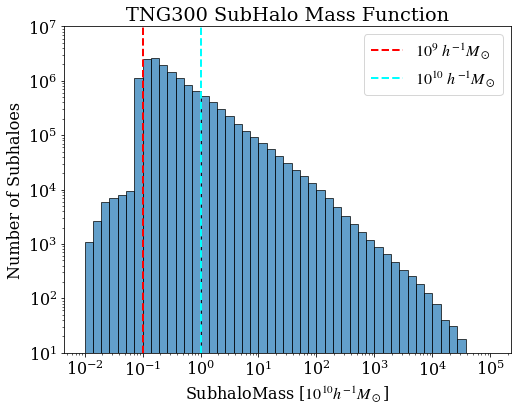

In [91]:
plt.figure(figsize=(8, 6))
plt.hist(subhalo_mass, bins=log_bins, edgecolor='black', alpha=0.7, log=True)  # log=True for log-scale y-axis

plt.ylim(1e1, 1e7)

# Step 4: Formatting
plt.xscale("log")  # Log scale on x-axis
plt.xlabel(r'SubhaloMass [$10^{10} h^{-1} M_\odot $]')
plt.ylabel("Number of Subhaloes")
plt.title("TNG300 SubHalo Mass Function")
#plt.grid(True, which="both", linestyle="--", linewidth=0.5)
# Step 4: Add Vertical Line at 10^(-1)
plt.axvline(x=10**-1, color='red', linestyle='--', linewidth=2, label=r'$10^{9}~ h^{-1} M_\odot$')
plt.axvline(x=10**0, color='cyan', linestyle='--', linewidth=2, label=r'$10^{10}~ h^{-1} M_\odot$')
plt.legend()  # Show legend for the vertical line

# Step 5: Save the Figure as PDF
plt.savefig("tng300_subhalo_massfunc.pdf", format="pdf", bbox_inches="tight")
plt.savefig("tng300_subhalo_massfunc.png", format="png", bbox_inches="tight")


# Step 6: Show Plot
plt.show()

- Simulation Completeness Limit near $10^{-9} M_\odot$.
- Let's say `subhalo` as `galaxy` for convenience.

### Explode SubhaloMassType

In [16]:
# Define the band names
mass_names = ["m_gas", "m_dm", "dummy", "tr_dummy", "m_star", "m_bh"]

In [17]:
# Select and create new columns
for idx, mtype in enumerate(mass_names):
    rawdf = rawdf.withColumn(mtype, F.col('SubhaloMassType').getItem(idx))

In [18]:
%%time
rawdf.select(['SubhaloMass',"m_dm", "m_gas", "m_star", "m_bh"]).show(5,truncate=False)

+-----------+----------+----------+-----------+------------+
|SubhaloMass|m_dm      |m_gas     |m_star     |m_bh        |
+-----------+----------+----------+-----------+------------+
|0.17527081 |0.17527081|0.0       |0.0        |0.0         |
|8.560058   |7.735816  |0.80635756|0.017060202|8.238204E-4 |
|0.1872211  |0.1872211 |0.0       |0.0        |0.0         |
|9.599063   |8.974662  |0.6060134 |0.017164726|0.0012226128|
|0.11950283 |0.11950283|0.0       |0.0        |0.0         |
+-----------+----------+----------+-----------+------------+
only showing top 5 rows

CPU times: user 1.6 ms, sys: 780 µs, total: 2.38 ms
Wall time: 208 ms


- Subhalo Types: DM only, DM + Gas, DM + Gas + Star, DM + Gas + Star + BH 
- `isubhalotype` code: DM +1, Gas +4, Star +8, BH +16; e.g., DM + Gas = 5, DM + Gas + Star = 13

#### Plot the histograms of `SubhaloMassType`

In [19]:
%%time
# Step 1: Convert 'SubhaloMass' to Pandas
mdm = rawdf.select("m_dm").toPandas()["m_dm"]
mgas = rawdf.select("m_gas").toPandas()["m_gas"]
mstar = rawdf.select("m_star").toPandas()["m_star"]
mbh = rawdf.select("m_bh").toPandas()["m_bh"]

CPU times: user 288 ms, sys: 143 ms, total: 431 ms
Wall time: 40.6 s


In [20]:
(mdm>0.0).sum(),(mgas>0.0).sum(),(mstar>0.0).sum(),(mbh>0.0).sum()

(14439075, 4588432, 1947928, 697798)

In [79]:
# Step 2: Define Log-Spaced Bins
num_bins = 50  # Adjust as needed
#log_bins = np.logspace(np.log10(subhalo_mass.min()), np.log10(subhalo_mass.max()), num_bins)
log_bins = np.logspace(np.log10(0.0001), np.log10(1e5), num_bins)

In [80]:
# plot settings
plt.rc('font', family='serif') 
#plt.rc('font', serif='Times New Roman') 
plt.rcParams.update({'font.size': 16})
plt.rcParams['mathtext.fontset'] = 'stix'

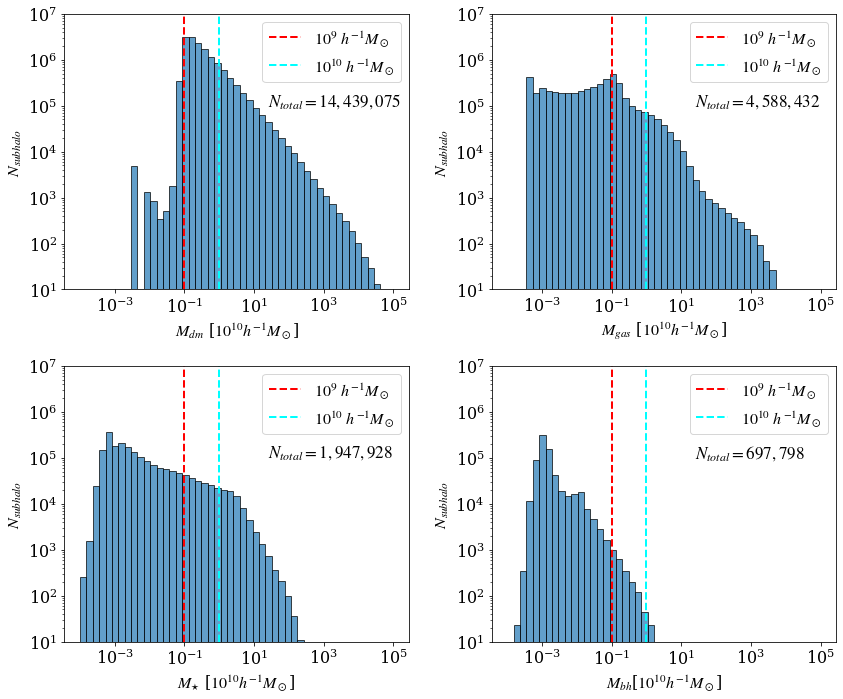

In [81]:
# Compute the number of nonzero subhaloes for each mass component
n_tot_mdm = (mdm > 0).sum()
n_tot_mgas = (mgas > 0).sum()
n_tot_mstar = (mstar > 0).sum()
n_tot_mbh = (mbh > 0).sum()

# Create a 2x2 figure
fig, axes = plt.subplots(2, 2, figsize=(12, 10))



# ---- Panel 1: Dark Matter Mass ----
ax1 = axes[0, 0]
ax1.set_ylim(1e1, 1e7)

ax1.hist(mdm, bins=log_bins, edgecolor='black', alpha=0.7, log=True)

ax1.set_xscale("log")
ax1.set_xlabel(r'$M_{dm}$ [$10^{10} h^{-1} M_\odot $]')
ax1.set_ylabel(r'$N_{subhalo}$')
#ax1.set_title("TNG300 Dark Matter Mass Function")
ax1.axvline(x=10**-1, color='red', linestyle='--', linewidth=2, label=r'$10^{9}~ h^{-1} M_\odot$')
ax1.axvline(x=10**0, color='cyan', linestyle='--', linewidth=2, label=r'$10^{10}~ h^{-1} M_\odot$')
ax1.legend()

# Add text to panel 1 (Top-left)
ax1.text(0.59, 0.72,f'$N_{{total}} = {n_tot_mdm:,}$', transform=ax1.transAxes, fontsize=17, verticalalignment='top')


# ---- Panel 2: Gas Mass ----
ax2 = axes[0, 1]
ax2.set_ylim(1e1, 1e7)

ax2.hist(mgas, bins=log_bins, edgecolor='black', alpha=0.7, log=True)
ax2.set_xscale("log")
ax2.set_xlabel(r'$M_{gas}$ [$10^{10} h^{-1} M_\odot $]')
ax2.set_ylabel(r'$N_{subhalo}$')
#ax2.set_title("TNG300 Gas Mass Function")
ax2.axvline(x=10**-1, color='red', linestyle='--', linewidth=2, label=r'$10^{9}~ h^{-1} M_\odot$')
ax2.axvline(x=10**0, color='cyan', linestyle='--', linewidth=2, label=r'$10^{10}~ h^{-1} M_\odot$')
ax2.legend()
# Add text to panel 1 (Top-left)
ax2.text(0.59, 0.72,f'$N_{{total}} = {n_tot_mgas:,}$', transform=ax2.transAxes, fontsize=17, verticalalignment='top')


# ---- Panel 3: Stellar Mass ----
ax3 = axes[1, 0]
ax3.set_ylim(1e1, 1e7)

ax3.hist(mstar, bins=log_bins, edgecolor='black', alpha=0.7, log=True)
ax3.set_xscale("log")
ax3.set_xlabel(r'$M_{\star}$ [$10^{10} h^{-1} M_\odot $]')
ax3.set_ylabel(r'$N_{subhalo}$')
#ax3.set_title("TNG300 Stellar Mass Function")
ax3.axvline(x=10**-1, color='red', linestyle='--', linewidth=2, label=r'$10^{9}~ h^{-1} M_\odot$')
ax3.axvline(x=10**0, color='cyan', linestyle='--', linewidth=2, label=r'$10^{10}~ h^{-1} M_\odot$')
ax3.legend()
# Add text to panel 1 (Top-left)
ax3.text(0.59, 0.72,f'$N_{{total}} = {n_tot_mstar:,}$', transform=ax3.transAxes, fontsize=17, verticalalignment='top')


# ---- Panel 4: Black Hole Mass ----
ax4 = axes[1, 1]
ax4.set_ylim(1e1, 1e7)

ax4.hist(mbh, bins=log_bins, edgecolor='black', alpha=0.7, log=True)
ax4.set_xscale("log")
ax4.set_xlabel(r'$M_{bh}$[$10^{10} h^{-1} M_\odot $]')
ax4.set_ylabel(r'$N_{subhalo}$')
#ax4.set_title("TNG300 Black Hole Mass Function")
ax4.axvline(x=10**-1, color='red', linestyle='--', linewidth=2, label=r'$10^{9}~ h^{-1} M_\odot$')
ax4.axvline(x=10**0, color='cyan', linestyle='--', linewidth=2, label=r'$10^{10}~ h^{-1} M_\odot$')
ax4.legend()
# Add text to panel 1 (Top-left)
ax4.text(0.59, 0.72,f'$N_{{total}} = {n_tot_mbh:,}$', transform=ax4.transAxes, fontsize=17, verticalalignment='top')



# Adjust layout to prevent overlap
plt.tight_layout()

# Save the Figure as PDF and PNG
plt.savefig("tng300-all-type-massfunc.pdf", format="pdf", bbox_inches="tight")
plt.savefig("tng300-all-type-massfunc.png", format="png", bbox_inches="tight")

# Show the figure
plt.show()

#### Assigning `isubhalotype`

In [24]:
# Compute `isubhalotype`
rawdf = rawdf.withColumn(
    "isubhalotype",
    (F.when(F.col("m_dm") > 0, 1).otherwise(0) +
     F.when(F.col("m_gas") > 0, 4).otherwise(0) +
     F.when(F.col("m_star") > 0, 8).otherwise(0) +
     F.when(F.col("m_bh") > 0, 16).otherwise(0))
)

In [25]:
%%time
rawdf.select(['SubhaloMass',"m_dm", "m_gas", "m_star", "m_bh",'isubhalotype']) \
.show(5,truncate=False)

+-----------+----------+----------+-----------+------------+------------+
|SubhaloMass|m_dm      |m_gas     |m_star     |m_bh        |isubhalotype|
+-----------+----------+----------+-----------+------------+------------+
|0.17527081 |0.17527081|0.0       |0.0        |0.0         |1           |
|8.560058   |7.735816  |0.80635756|0.017060202|8.238204E-4 |29          |
|0.1872211  |0.1872211 |0.0       |0.0        |0.0         |1           |
|9.599063   |8.974662  |0.6060134 |0.017164726|0.0012226128|29          |
|0.11950283 |0.11950283|0.0       |0.0        |0.0         |1           |
+-----------+----------+----------+-----------+------------+------------+
only showing top 5 rows

CPU times: user 131 µs, sys: 2.66 ms, total: 2.79 ms
Wall time: 157 ms


In [26]:
# Compute the group count for each `isubhalotype`
hist_subtype_df = rawdf.groupBy("isubhalotype").agg(F.count("*").alias("count"))
hist_subtype_df = hist_subtype_df.orderBy(F.col("count").desc())

In [27]:
%%time
hist_subtype_pdf = hist_subtype_df.toPandas()

CPU times: user 0 ns, sys: 6.31 ms, total: 6.31 ms
Wall time: 11.1 s


In [28]:
hist_subtype_pdf.sort_values(by="isubhalotype", ascending=True)

,isubhalotype,count
0,1,9245720
9,4,8749
1,5,3267700
8,8,12899
4,9,586390
6,12,24952
2,13,641501
10,17,2256
7,21,13356
12,24,14


In [29]:
# plot settings
plt.rc('font', family='serif') 
#plt.rc('font', serif='Times New Roman') 
plt.rcParams.update({'font.size': 14})
plt.rcParams['mathtext.fontset'] = 'stix'

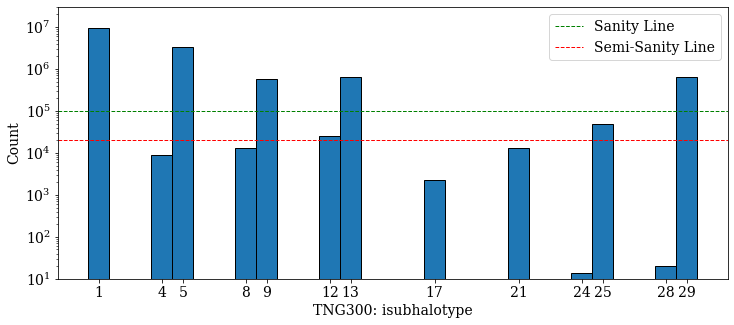

In [30]:
# Plot histogram
plt.figure(figsize=(12, 5))
plt.yscale("log")
plt.bar(hist_subtype_pdf["isubhalotype"], hist_subtype_pdf["count"], width=1.0, edgecolor="black")
plt.axhline(y=1e5, color='green', linestyle='--', linewidth=1, label='Sanity Line') 
plt.axhline(y=2e4, color='red', linestyle='--', linewidth=1, label='Semi-Sanity Line')
plt.xlabel("TNG300: isubhalotype")
plt.ylabel("Count")
plt.legend(loc=0)
plt.ylim(1e1, 3e7)
#plt.title("Histogram of isubhalotype Counts")
plt.xticks(hist_subtype_pdf["isubhalotype"])  # Ensure all x-ticks are displayed

# Save the Figure as PDF and PNG
plt.savefig("tng300-all-type-stats.pdf", format="pdf", bbox_inches="tight")
plt.savefig("tng300-all-type-stats.png", format="png", bbox_inches="tight")

plt.show()

- **1: DM only**
- 4: Gas only (what?!?)
- **5: DM + Gas**
- 8: Star only (what?!?)
- *9:* **DM + Star (no gas?!? strong feedback?)**
- *12: Gas + Star (no dm?!?, tidally stripped subhalo?)*
- **13: DM + Gas + Star (good)** 
- 17: DM + BH (what?!?)
- 21: DM + Gas + BH (no star?!? what?!?) 
- 24: Star + BH (what?!?) 
- *25:* **DM + Star + BH (no gas?!? even stronger feedback?)**
- 28: Gas + Star + BH 
- **29: DM + Gas + Star + BH**

In [31]:
hist_subtype_pdf

,isubhalotype,count
0,1,9245720
1,5,3267700
2,13,641501
3,29,632154
4,9,586390
5,25,49998
6,12,24952
7,21,13356
8,8,12899
9,4,8749


#### MassFunction for each type

In [32]:
%%time
# Step 1: Convert 'SubhaloMass' to Pandas
dm = rawdf.filter(rawdf.isubhalotype == 1).select("SubhaloMass").toPandas()["SubhaloMass"]
dmgas = rawdf.filter(rawdf.isubhalotype == 5).select("SubhaloMass").toPandas()["SubhaloMass"]
dmgasstar = rawdf.filter(rawdf.isubhalotype == 13).select("SubhaloMass").toPandas()["SubhaloMass"]
dmgasstarbh = rawdf.filter(rawdf.isubhalotype == 29).select("SubhaloMass").toPandas()["SubhaloMass"]

CPU times: user 136 ms, sys: 49.4 ms, total: 185 ms
Wall time: 42.6 s


In [92]:
# Step 2: Define Log-Spaced Bins
num_bins = 50  # Adjust as needed
#log_bins = np.logspace(np.log10(subhalo_mass.min()), np.log10(subhalo_mass.max()), num_bins)
log_bins = np.logspace(np.log10(0.01), np.log10(1e5), num_bins)

In [93]:
# plot settings
plt.rc('font', family='serif') 
#plt.rc('font', serif='Times New Roman') 
plt.rcParams.update({'font.size': 14})
plt.rcParams['mathtext.fontset'] = 'stix'

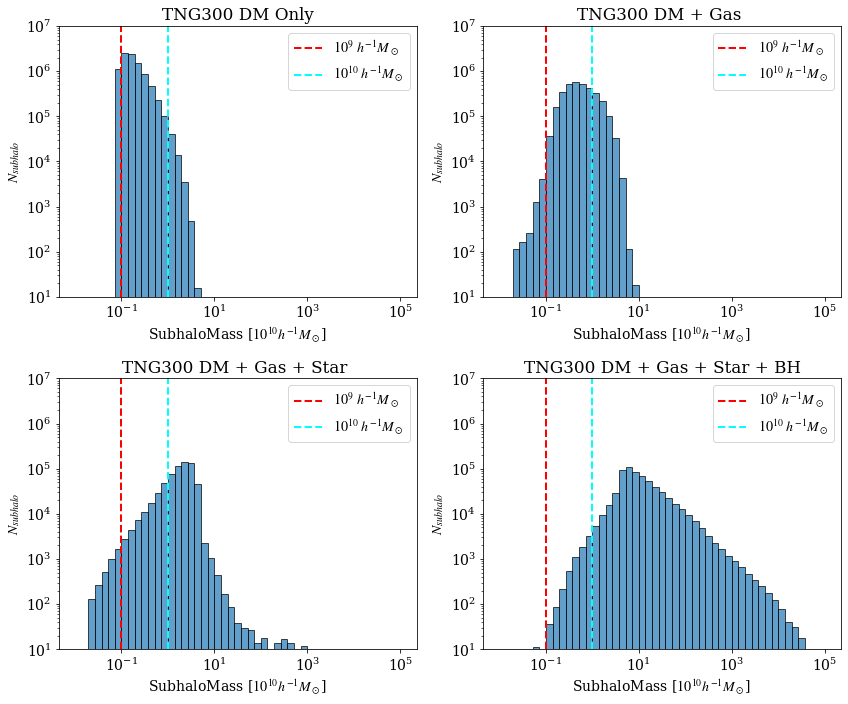

In [94]:
# Create a 2x2 figure
fig, axes = plt.subplots(2, 2, figsize=(12, 10))


# ---- Panel 1: Dark Matter Mass ----
ax1 = axes[0, 0]
ax1.hist(dm, bins=log_bins, edgecolor='black', alpha=0.7, log=True)

ax1.set_ylim(1e1, 1e7)
ax1.set_xscale("log")
ax1.set_xlabel(r'SubhaloMass [$10^{10} h^{-1} M_\odot $]')
ax1.set_ylabel(r'$N_{subhalo}$')
ax1.set_title("TNG300 DM Only")
ax1.axvline(x=10**-1, color='red', linestyle='--', linewidth=2, label=r'$10^{9}~ h^{-1} M_\odot$')
ax1.axvline(x=10**0, color='cyan', linestyle='--', linewidth=2, label=r'$10^{10}~ h^{-1} M_\odot$')
ax1.legend()

# Add text to panel 1 (Top-left)
#ax1.text(0.59, 0.72,f'$N_{{total}} = {n_tot_mdm:,}$', transform=ax1.transAxes, fontsize=17, verticalalignment='top')

#-----------
ax2 = axes[0, 1]
ax2.hist(dmgas, bins=log_bins, edgecolor='black', alpha=0.7, log=True)

ax2.set_ylim(1e1, 1e7)
ax2.set_xscale("log")
ax2.set_xlabel(r'SubhaloMass [$10^{10} h^{-1} M_\odot $]')
ax2.set_ylabel(r'$N_{subhalo}$')
ax2.set_title("TNG300 DM + Gas ")
ax2.axvline(x=10**-1, color='red', linestyle='--', linewidth=2, label=r'$10^{9}~ h^{-1} M_\odot$')
ax2.axvline(x=10**0, color='cyan', linestyle='--', linewidth=2, label=r'$10^{10}~ h^{-1} M_\odot$')
ax2.legend()

#------------
ax3 = axes[1, 0]
ax3.hist(dmgasstar, bins=log_bins, edgecolor='black', alpha=0.7, log=True)

ax3.set_ylim(1e1, 1e7)
ax3.set_xscale("log")
ax3.set_xlabel(r'SubhaloMass [$10^{10} h^{-1} M_\odot $]')
ax3.set_ylabel(r'$N_{subhalo}$')
ax3.set_title("TNG300 DM + Gas + Star ")
ax3.axvline(x=10**-1, color='red', linestyle='--', linewidth=2, label=r'$10^{9}~ h^{-1} M_\odot$')
ax3.axvline(x=10**0, color='cyan', linestyle='--', linewidth=2, label=r'$10^{10}~ h^{-1} M_\odot$')
ax3.legend()


#------------
ax4 = axes[1, 1]
ax4.hist(dmgasstarbh, bins=log_bins, edgecolor='black', alpha=0.7, log=True)

ax4.set_ylim(1e1, 1e7)
ax4.set_xscale("log")
ax4.set_xlabel(r'SubhaloMass [$10^{10} h^{-1} M_\odot $]')
ax4.set_ylabel(r'$N_{subhalo}$')
ax4.set_title("TNG300 DM + Gas + Star + BH")
ax4.axvline(x=10**-1, color='red', linestyle='--', linewidth=2, label=r'$10^{9}~ h^{-1} M_\odot$')
ax4.axvline(x=10**0, color='cyan', linestyle='--', linewidth=2, label=r'$10^{10}~ h^{-1} M_\odot$')
ax4.legend()


# Adjust layout to prevent overlap
plt.tight_layout()

# Save the Figure as PDF and PNG
plt.savefig("tng300-isubhalotype-massfunc.pdf", format="pdf", bbox_inches="tight")
plt.savefig("tng300-isubhalotype-massfunc.png", format="png", bbox_inches="tight")

# Show the figure
plt.show()

In [47]:
%%time
# Step 1: Convert 'SubhaloMass' to Pandas
dmstar = rawdf.filter(rawdf.isubhalotype == 9).select("SubhaloMass").toPandas()["SubhaloMass"]
dmstarbh = rawdf.filter(rawdf.isubhalotype == 25).select("SubhaloMass").toPandas()["SubhaloMass"]
gasstar = rawdf.filter(rawdf.isubhalotype == 12).select("SubhaloMass").toPandas()["SubhaloMass"]
dmgasbh = rawdf.filter(rawdf.isubhalotype == 21).select("SubhaloMass").toPandas()["SubhaloMass"]

CPU times: user 49.4 ms, sys: 9.19 ms, total: 58.6 ms
Wall time: 41 s


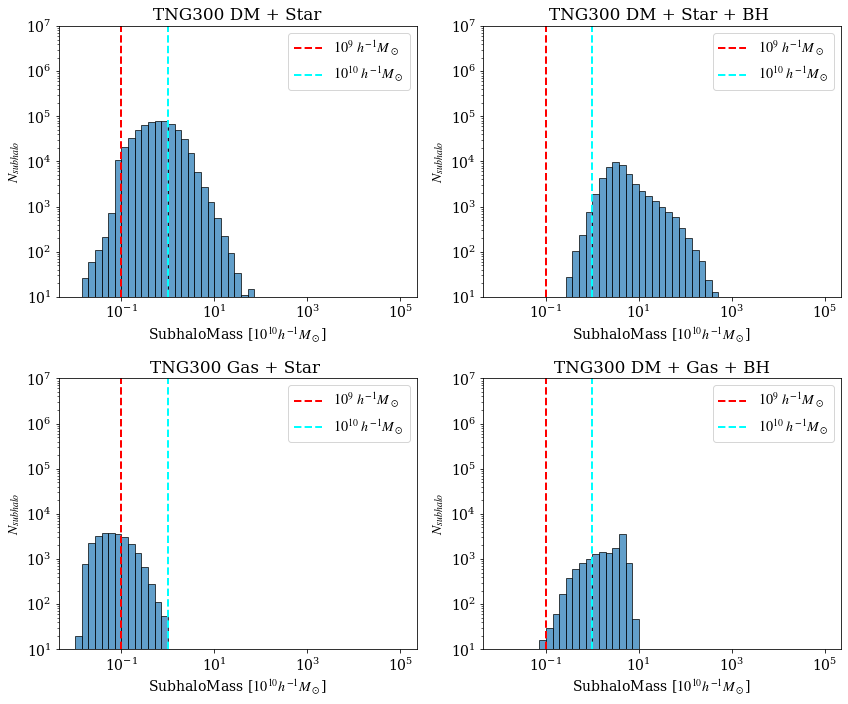

In [95]:
# Create a 2x2 figure
fig, axes = plt.subplots(2, 2, figsize=(12, 10))


# ---- Panel 1: Dark Matter Mass ----
ax1 = axes[0, 0]
ax1.hist(dmstar, bins=log_bins, edgecolor='black', alpha=0.7, log=True)

ax1.set_ylim(1e1, 1e7)

ax1.set_xscale("log")
ax1.set_xlabel(r'SubhaloMass [$10^{10} h^{-1} M_\odot $]')
ax1.set_ylabel(r'$N_{subhalo}$')
ax1.set_title("TNG300 DM + Star")
ax1.axvline(x=10**-1, color='red', linestyle='--', linewidth=2, label=r'$10^{9}~ h^{-1} M_\odot$')
ax1.axvline(x=10**0, color='cyan', linestyle='--', linewidth=2, label=r'$10^{10}~ h^{-1} M_\odot$')
ax1.legend()

# Add text to panel 1 (Top-left)
#ax1.text(0.59, 0.72,f'$N_{{total}} = {n_tot_mdm:,}$', transform=ax1.transAxes, fontsize=17, verticalalignment='top')

#-----------
ax2 = axes[0, 1]
ax2.hist(dmstarbh, bins=log_bins, edgecolor='black', alpha=0.7, log=True)

ax2.set_ylim(1e1, 1e7)

ax2.set_xscale("log")
ax2.set_xlabel(r'SubhaloMass [$10^{10} h^{-1} M_\odot $]')
ax2.set_ylabel(r'$N_{subhalo}$')
ax2.set_title("TNG300 DM + Star + BH ")
ax2.axvline(x=10**-1, color='red', linestyle='--', linewidth=2, label=r'$10^{9}~ h^{-1} M_\odot$')
ax2.axvline(x=10**0, color='cyan', linestyle='--', linewidth=2, label=r'$10^{10}~ h^{-1} M_\odot$')
ax2.legend()

#------------
ax3 = axes[1, 0]
ax3.hist(gasstar, bins=log_bins, edgecolor='black', alpha=0.7, log=True)

ax3.set_ylim(1e1, 1e7)

ax3.set_xscale("log")
ax3.set_xlabel(r'SubhaloMass [$10^{10} h^{-1} M_\odot $]')
ax3.set_ylabel(r'$N_{subhalo}$')
ax3.set_title("TNG300 Gas + Star ")
ax3.axvline(x=10**-1, color='red', linestyle='--', linewidth=2, label=r'$10^{9}~ h^{-1} M_\odot$')
ax3.axvline(x=10**0, color='cyan', linestyle='--', linewidth=2, label=r'$10^{10}~ h^{-1} M_\odot$')
ax3.legend()


#------------
ax4 = axes[1, 1]
ax4.hist(dmgasbh, bins=log_bins, edgecolor='black', alpha=0.7, log=True)

ax4.set_ylim(1e1, 1e7)

ax4.set_xscale("log")
ax4.set_xlabel(r'SubhaloMass [$10^{10} h^{-1} M_\odot $]')
ax4.set_ylabel(r'$N_{subhalo}$')
ax4.set_title("TNG300 DM + Gas + BH")
ax4.axvline(x=10**-1, color='red', linestyle='--', linewidth=2, label=r'$10^{9}~ h^{-1} M_\odot$')
ax4.axvline(x=10**0, color='cyan', linestyle='--', linewidth=2, label=r'$10^{10}~ h^{-1} M_\odot$')
ax4.legend()


# Adjust layout to prevent overlap
plt.tight_layout()

# Save the Figure as PDF and PNG
plt.savefig("tng300-isubhalotype-abnormal-massfunc.pdf", format="pdf", bbox_inches="tight")
plt.savefig("tng300-isubhalotype-abnormal-massfunc.png", format="png", bbox_inches="tight")

# Show the figure
plt.show()

## Photometry and Bimodality 

In [58]:
%%time
rawdf.select(['m_star','SubhaloStellarPhotometrics']).show(5,truncate=False)

+-----------+------------------------------------------------------------------------------------------------+
|m_star     |SubhaloStellarPhotometrics                                                                      |
+-----------+------------------------------------------------------------------------------------------------+
|0.0        |[1.0E37, 1.0E37, 1.0E37, 1.0E37, 1.0E37, 1.0E37, 1.0E37, 1.0E37]                                |
|0.017060202|[-15.64946, -15.761063, -16.289967, -18.417833, -16.08965, -16.512243, -16.707237, -16.8231]    |
|0.0        |[1.0E37, 1.0E37, 1.0E37, 1.0E37, 1.0E37, 1.0E37, 1.0E37, 1.0E37]                                |
|0.017164726|[-15.651502, -15.766202, -16.270811, -18.349117, -16.087048, -16.482414, -16.667686, -16.779137]|
|0.0        |[1.0E37, 1.0E37, 1.0E37, 1.0E37, 1.0E37, 1.0E37, 1.0E37, 1.0E37]                                |
+-----------+------------------------------------------------------------------------------------------------+
o

### Explode `SubhaloStellarPhotometrics`

In [59]:
# Define the band names
band_names = ["U", "B", "V", "K", "g", "r", "i", "z"]

In [60]:
# Select and create new columns
for idx, band in enumerate(band_names):
    rawdf = rawdf.withColumn(band, F.col("SubhaloStellarPhotometrics").getItem(idx))

In [61]:
%%time
rawdf.select(['m_star',"U", "B", "V", "K", "g", "r", "i", "z"]).show(5,truncate=False)

+-----------+----------+----------+----------+----------+----------+----------+----------+----------+
|m_star     |U         |B         |V         |K         |g         |r         |i         |z         |
+-----------+----------+----------+----------+----------+----------+----------+----------+----------+
|0.0        |1.0E37    |1.0E37    |1.0E37    |1.0E37    |1.0E37    |1.0E37    |1.0E37    |1.0E37    |
|0.017060202|-15.64946 |-15.761063|-16.289967|-18.417833|-16.08965 |-16.512243|-16.707237|-16.8231  |
|0.0        |1.0E37    |1.0E37    |1.0E37    |1.0E37    |1.0E37    |1.0E37    |1.0E37    |1.0E37    |
|0.017164726|-15.651502|-15.766202|-16.270811|-18.349117|-16.087048|-16.482414|-16.667686|-16.779137|
|0.0        |1.0E37    |1.0E37    |1.0E37    |1.0E37    |1.0E37    |1.0E37    |1.0E37    |1.0E37    |
+-----------+----------+----------+----------+----------+----------+----------+----------+----------+
only showing top 5 rows

CPU times: user 2.92 ms, sys: 0 ns, total: 2.92 ms
Wall t

## Color Color Bimodality 

In [62]:
%%time
rawdf.select(['m_star','SubhaloSFR']).show(5,truncate=False)

+-----------+------------+
|m_star     |SubhaloSFR  |
+-----------+------------+
|0.0        |0.0         |
|0.017060202|0.023696147 |
|0.0        |0.0         |
|0.017164726|0.0051953103|
|0.0        |0.0         |
+-----------+------------+
only showing top 5 rows

CPU times: user 2.76 ms, sys: 0 ns, total: 2.76 ms
Wall time: 110 ms


In [64]:
%%time
rawdf.select(['m_star','SubhaloSFR']).describe().show()

+-------+-------------------+--------------------+
|summary|             m_star|          SubhaloSFR|
+-------+-------------------+--------------------+
|  count|           14485709|            14485709|
|   mean|0.02586335211579545|0.011810388825962165|
| stddev| 0.6472265171887863| 0.17409765650964873|
|    min|                0.0|                 0.0|
|    max|           530.9484|             59.2189|
+-------+-------------------+--------------------+

CPU times: user 3.4 ms, sys: 0 ns, total: 3.4 ms
Wall time: 9.72 s


### SFR vs. Stellar Mass

In [156]:
%%time
# Convert to Pandas and remove rows with zero or negative values
pdf = rawdf.select(['m_star', 'SubhaloSFR']).toPandas()
pdf = pdf[(pdf["m_star"] > 0) & (pdf["SubhaloSFR"] > 0)]  # Remove zeros & negatives
pdf = pdf.dropna()  # Remove any NaN values
# Convert data to log10 scale
pdf["log_m_star"] = np.log10(pdf["m_star"])
pdf["log_SubhaloSFR"] = np.log10(pdf["SubhaloSFR"])

CPU times: user 118 ms, sys: 143 ms, total: 261 ms
Wall time: 10.2 s


In [97]:
pdf.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 552121 entries, 1 to 14472212
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   m_star          552121 non-null  float32
 1   SubhaloSFR      552121 non-null  float32
 2   log_m_star      552121 non-null  float32
 3   log_SubhaloSFR  552121 non-null  float32
dtypes: float32(4)
memory usage: 12.6 MB


In [100]:
%%time
# Convert to Pandas and remove rows with zero or negative values
dgs = rawdf.filter(rawdf.isubhalotype == 13).select(['m_star', 'SubhaloSFR']).toPandas()
dgs = dgs[(dgs["m_star"] > 0) & (dgs["SubhaloSFR"] > 0)]  # Remove zeros & negatives
dgs = dgs.dropna()  # Remove any NaN values
# Convert data to log10 scale
dgs["log_m_star"] = np.log10(dgs["m_star"])
dgs["log_SubhaloSFR"] = np.log10(dgs["SubhaloSFR"])

CPU times: user 27.8 ms, sys: 7.64 ms, total: 35.5 ms
Wall time: 10.3 s


In [101]:
dgs.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 75462 entries, 2 to 641499
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   m_star          75462 non-null  float32
 1   SubhaloSFR      75462 non-null  float32
 2   log_m_star      75462 non-null  float32
 3   log_SubhaloSFR  75462 non-null  float32
dtypes: float32(4)
memory usage: 1.7 MB


In [102]:
%%time
# Convert to Pandas and remove rows with zero or negative values
dgsb = rawdf.filter(rawdf.isubhalotype == 29).select(['m_star', 'SubhaloSFR']).toPandas()
dgsb = dgsb[(dgsb["m_star"] > 0) & (dgsb["SubhaloSFR"] > 0)]  # Remove zeros & negatives
dgsb = dgsb.dropna()  # Remove any NaN values
# Convert data to log10 scale
dgsb["log_m_star"] = np.log10(dgsb["m_star"])
dgsb["log_SubhaloSFR"] = np.log10(dgsb["SubhaloSFR"])

CPU times: user 31.5 ms, sys: 5.08 ms, total: 36.6 ms
Wall time: 9.56 s


In [103]:
dgsb.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 453720 entries, 0 to 632153
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   m_star          453720 non-null  float32
 1   SubhaloSFR      453720 non-null  float32
 2   log_m_star      453720 non-null  float32
 3   log_SubhaloSFR  453720 non-null  float32
dtypes: float32(4)
memory usage: 10.4 MB


In [106]:
%%time
# Convert to Pandas and remove rows with zero or negative values
gs = rawdf.filter(rawdf.isubhalotype == 12).select(['m_star', 'SubhaloSFR']).toPandas()
gs = gs[(gs["m_star"] > 0) & (gs["SubhaloSFR"] > 0)]  # Remove zeros & negatives
gs = gs.dropna()  # Remove any NaN values
# Convert data to log10 scale
gs["log_m_star"] = np.log10(gs["m_star"])
gs["log_SubhaloSFR"] = np.log10(gs["SubhaloSFR"])

CPU times: user 13.6 ms, sys: 3 ms, total: 16.6 ms
Wall time: 9.81 s


In [107]:
gs.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 22919 entries, 0 to 24951
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   m_star          22919 non-null  float32
 1   SubhaloSFR      22919 non-null  float32
 2   log_m_star      22919 non-null  float32
 3   log_SubhaloSFR  22919 non-null  float32
dtypes: float32(4)
memory usage: 537.2 KB


In [109]:
%%time
# Convert to Pandas and remove rows with zero or negative values
dsb = rawdf.filter(rawdf.isubhalotype == 25).select(['m_star', 'SubhaloSFR']).toPandas()
dsb = dsb[(dsb["m_star"] > 0) & (dsb["SubhaloSFR"] > 0)]  # Remove zeros & negatives
dsb = dsb.dropna()  # Remove any NaN values
# Convert data to log10 scale
dsb["log_m_star"] = np.log10(dsb["m_star"])
dsb["log_SubhaloSFR"] = np.log10(dsb["SubhaloSFR"])

CPU times: user 14.1 ms, sys: 2.52 ms, total: 16.6 ms
Wall time: 10 s


In [110]:
dsb.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 0 entries
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   m_star          0 non-null      float32
 1   SubhaloSFR      0 non-null      float32
 2   log_m_star      0 non-null      float32
 3   log_SubhaloSFR  0 non-null      float32
dtypes: float32(4)
memory usage: 0.0 bytes


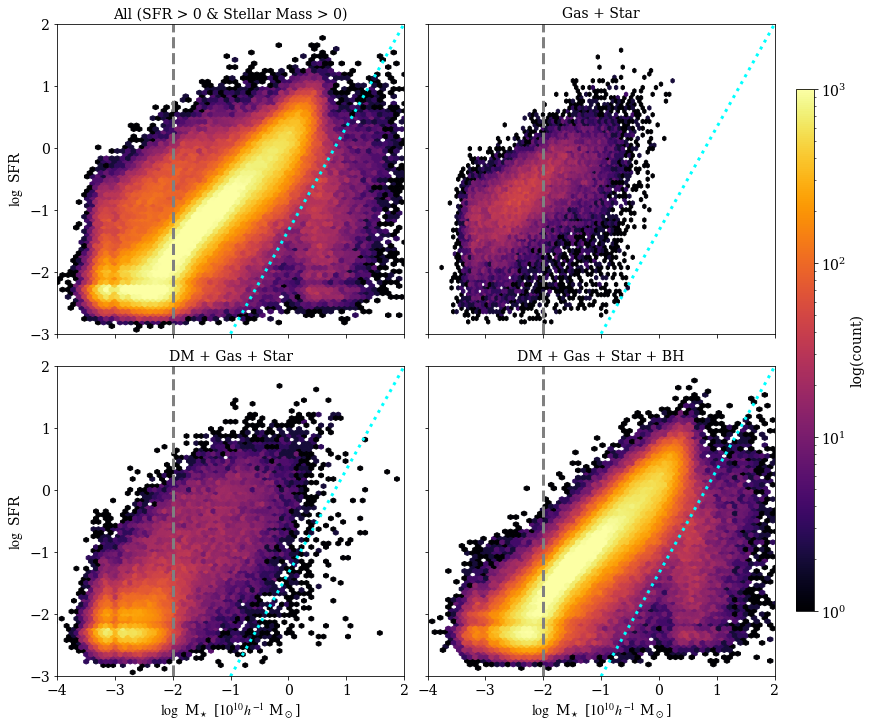

In [125]:
# Create a 2×2 figure
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True, constrained_layout=True)

# Define datasets and titles for each panel
datasets = [pdf, gs, dgs, dgsb]
titles = ["All (SFR > 0 & Stellar Mass > 0)", "Gas + Star", \
          "DM + Gas + Star", "DM + Gas + Star + BH"]

# Loop through each subplot manually
for ax, data, title in zip(axes.flatten(), datasets, titles):
    # Create hexbin plot
    hb = ax.hexbin(data["log_m_star"], data["log_SubhaloSFR"], gridsize=70, 
                   cmap='inferno', bins='log', mincnt=1, vmin=1, vmax=1000)

    # Overplot reference lines
    ax.axvline(x=-2, color='grey', linestyle='--', linewidth=3)
    ax.plot([-1, 2], [-3, 2], color='cyan', linestyle=':', linewidth=3)

    # Set axis limits
    ax.set_xlim(-4, 2)
    ax.set_ylim(-3, 2)

    # Labels and title
    ax.set_title(title, fontsize=14)

# Set common x and y labels (only for bottom-left & left-most panels)
axes[1, 0].set_xlabel(r'$\log$ M$_\star$ [$10^{10} h^{-1}$ M$_\odot $]')
axes[1, 1].set_xlabel(r'$\log$ M$_\star$ [$10^{10} h^{-1}$ M$_\odot $]')
axes[0, 0].set_ylabel(r'$\log$ SFR')
axes[1, 0].set_ylabel(r'$\log$ SFR')

# Add a single colorbar for all panels
cbar = fig.colorbar(hb, ax=axes[:, -1], shrink=0.8, aspect=30, label='log(count)')

# Adjust layout
#plt.tight_layout()

# Save the Figure
plt.savefig("tng300_2x2_bimodality.pdf", format="pdf", bbox_inches="tight")
plt.savefig("tng300_2x2_bimodality.png", format="png", bbox_inches="tight")

# Show the plot
plt.show()

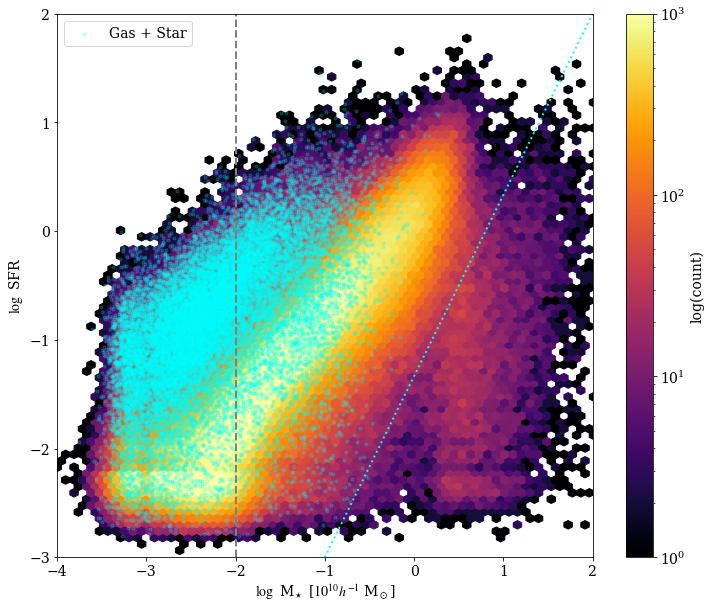

In [157]:

# Create hexbin plot on log-transformed values
plt.figure(figsize=(12,10))
hb = plt.hexbin(pdf["log_m_star"], pdf["log_SubhaloSFR"], gridsize=70, \
                cmap='inferno', bins='log', mincnt=1, vmin=1, vmax=1000)

plt.axvline(x=-2, color='grey', linestyle='--', linewidth=2)
# Plot the line from (-1, -2) to (2, 1)
plt.plot([-1, 2], [-3, 2], color='cyan', linestyle=':', linewidth=2)


# **Set X and Y limits (Modify values as needed)**
plt.xlim(-4, 2)  # Example: Log(Mass) from 10^8 to 10^12
plt.ylim(-3, 2)  # Example: Log(SFR) from 10^-3 to 10^2

# **No need for log scale on axes since data is already log-transformed**
plt.xlabel(r'$\log$ M$_\star$ [$10^{10} h^{-1}$ M$_\odot $]')
plt.ylabel(r'$\log$ SFR')
#plt.title("Hexbin Density Plot of Log-Converted SubhaloMass vs SubhaloSFR")

# Add color bar
plt.colorbar(label='log(count)')
# Overplot scatter plot for `isubhalotype == 29`
plt.scatter(gs["log_m_star"], gs["log_SubhaloSFR"], color='cyan', s=10, alpha=0.2, label="Gas + Star")

plt.legend(loc=0)

# Step 5: Save the Figure as PDF
plt.savefig("tng300_gs_bimordality.pdf", format="pdf", bbox_inches="tight")
plt.savefig("tng300_gs_bimordality.png", format="png", bbox_inches="tight")


# Show the plot
plt.show()

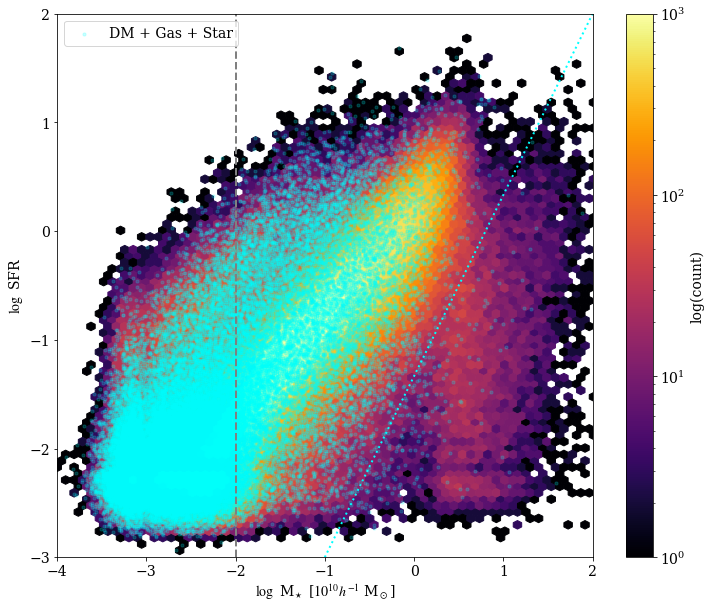

In [158]:

# Create hexbin plot on log-transformed values
plt.figure(figsize=(12,10))
hb = plt.hexbin(pdf["log_m_star"], pdf["log_SubhaloSFR"], gridsize=70, \
                cmap='inferno', bins='log', mincnt=1, vmin=1, vmax=1000)

plt.axvline(x=-2, color='grey', linestyle='--', linewidth=2)
# Plot the line from (-1, -2) to (2, 1)
plt.plot([-1, 2], [-3, 2], color='cyan', linestyle=':', linewidth=2)


# **Set X and Y limits (Modify values as needed)**
plt.xlim(-4, 2)  # Example: Log(Mass) from 10^8 to 10^12
plt.ylim(-3, 2)  # Example: Log(SFR) from 10^-3 to 10^2

# **No need for log scale on axes since data is already log-transformed**
plt.xlabel(r'$\log$ M$_\star$ [$10^{10} h^{-1}$ M$_\odot $]')
plt.ylabel(r'$\log$ SFR')
#plt.title("Hexbin Density Plot of Log-Converted SubhaloMass vs SubhaloSFR")

# Add color bar
plt.colorbar(label='log(count)')
# Overplot scatter plot for `isubhalotype == 29`
plt.scatter(dgs["log_m_star"], dgs["log_SubhaloSFR"], color='cyan', s=10, alpha=0.2, label="DM + Gas + Star")

plt.legend(loc=2)

# Step 5: Save the Figure as PDF
plt.savefig("tng300_dgs_bimordality.pdf", format="pdf", bbox_inches="tight")
plt.savefig("tng300_dgs_bimordality.png", format="png", bbox_inches="tight")


# Show the plot
plt.show()

### *u-r* color vs. Stellar Mass

#### define `df` for `m_star > 0`

In [134]:
df = rawdf.filter(rawdf.m_star >0)

In [135]:
df.cache()

DataFrame[SubhaloBHMass: float, SubhaloBHMdot: float, SubhaloBfldDisk: float, SubhaloBfldHalo: float, SubhaloCM: array<float>, SubhaloFlag: boolean, SubhaloGasMetalFractions: array<float>, SubhaloGasMetalFractionsHalfRad: array<float>, SubhaloGasMetalFractionsMaxRad: array<float>, SubhaloGasMetalFractionsSfr: array<float>, SubhaloGasMetalFractionsSfrWeighted: array<float>, SubhaloGasMetallicity: float, SubhaloGasMetallicityHalfRad: float, SubhaloGasMetallicityMaxRad: float, SubhaloGasMetallicitySfr: float, SubhaloGasMetallicitySfrWeighted: float, SubhaloGrNr: int, SubhaloHalfmassRad: float, SubhaloHalfmassRadType: array<float>, SubhaloIDMostbound: bigint, SubhaloLen: int, SubhaloLenType: array<int>, SubhaloMass: float, SubhaloMassInHalfRad: float, SubhaloMassInHalfRadType: array<float>, SubhaloMassInMaxRad: float, SubhaloMassInMaxRadType: array<float>, SubhaloMassInRad: float, SubhaloMassInRadType: array<float>, SubhaloMassType: array<float>, SubhaloParent: int, SubhaloPos: array<float

In [136]:
%%time
df.select(['m_star',"U", "r"]).show(5,truncate=False)

+------------+----------+----------+
|m_star      |U         |r         |
+------------+----------+----------+
|0.017060202 |-15.64946 |-16.512243|
|0.017164726 |-15.651502|-16.482414|
|0.00971152  |-14.73676 |-15.596527|
|0.0034237274|-14.014501|-14.8242  |
|0.0014575666|-13.335435|-14.134254|
+------------+----------+----------+
only showing top 5 rows

CPU times: user 2.95 ms, sys: 0 ns, total: 2.95 ms
Wall time: 951 ms


In [137]:
# Add `color_ur` column as U - r
df = df.withColumn("color_ur", F.col("U") - F.col("r"))

In [138]:
%%time
df.select(['m_star',"U", "r",'color_ur']).show(5,truncate=False)

+------------+----------+----------+----------+
|m_star      |U         |r         |color_ur  |
+------------+----------+----------+----------+
|0.017060202 |-15.64946 |-16.512243|0.86278343|
|0.017164726 |-15.651502|-16.482414|0.8309126 |
|0.00971152  |-14.73676 |-15.596527|0.85976696|
|0.0034237274|-14.014501|-14.8242  |0.80969906|
|0.0014575666|-13.335435|-14.134254|0.79881954|
+------------+----------+----------+----------+
only showing top 5 rows

CPU times: user 2.27 ms, sys: 298 µs, total: 2.57 ms
Wall time: 45.5 ms


In [139]:
%%time
df.select(["U", "r",'color_ur']).describe().show()

+-------+-------------------+------------------+-------------------+
|summary|                  U|                 r|           color_ur|
+-------+-------------------+------------------+-------------------+
|  count|            1947928|           1947928|            1947928|
|   mean|-13.675500155009303|-14.54919103459595| 0.8736908795866478|
| stddev|  2.696646742750441| 2.673582025597878|0.35050715785572034|
|    min|         -24.791388|         -26.37341|          -1.582365|
|    max|          -8.278189|         -9.162131|           2.235114|
+-------+-------------------+------------------+-------------------+

CPU times: user 1.38 ms, sys: 3.14 ms, total: 4.52 ms
Wall time: 17.5 s


In [160]:
%%time
# Convert to Pandas and remove rows with zero or negative values
ppdf = df.select(['m_star', 'color_ur']).toPandas()
ppdf = ppdf.dropna()  # Remove any NaN values
# Convert data to log10 scale
ppdf["log_m_star"] = np.log10(ppdf["m_star"])

CPU times: user 29.3 ms, sys: 21.3 ms, total: 50.6 ms
Wall time: 327 ms


In [161]:
ppdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1947928 entries, 0 to 1947927
Data columns (total 3 columns):
 #   Column      Dtype  
---  ------      -----  
 0   m_star      float32
 1   color_ur    float32
 2   log_m_star  float32
dtypes: float32(3)
memory usage: 22.3 MB


In [162]:
# plot settings
plt.rc('font', family='serif') 
#plt.rc('font', serif='Times New Roman') 
plt.rcParams.update({'font.size': 14})
plt.rcParams['mathtext.fontset'] = 'stix'

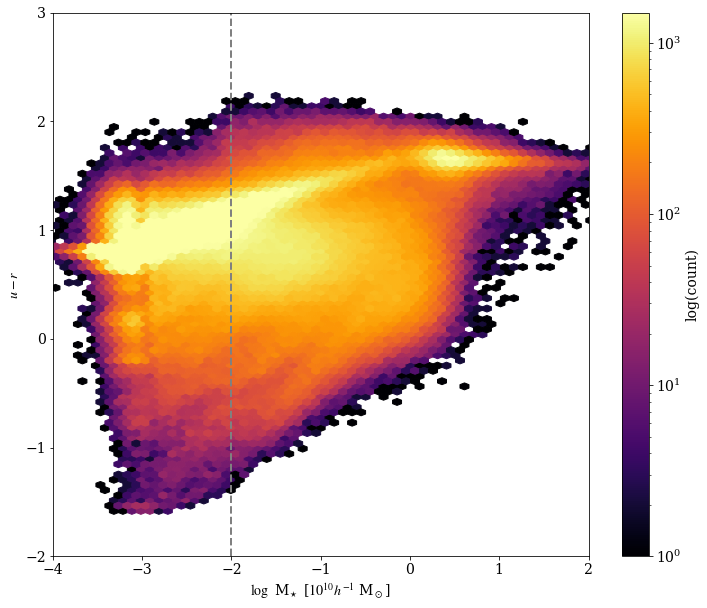

In [163]:
# Create hexbin plot on log-transformed values
plt.figure(figsize=(12,10))
hb = plt.hexbin(ppdf["log_m_star"], ppdf["color_ur"], gridsize=70, \
                cmap='inferno', bins='log', mincnt=1, vmin=1, vmax=1500)

plt.axvline(x=-2, color='grey', linestyle='--', linewidth=2)
# Plot the line from (-1, -2) to (2, 1)
#plt.plot([-1, 2], [-3, 2], color='cyan', linestyle=':', linewidth=2)


# **Set X and Y limits (Modify values as needed)**
plt.xlim(-4, 2)  # Example: Log(Mass) from 10^8 to 10^12
plt.ylim(-2, 3)  # Example: Log(SFR) from 10^-3 to 10^2

# **No need for log scale on axes since data is already log-transformed**
plt.xlabel(r'$\log$ M$_\star$ [$10^{10} h^{-1}$ M$_\odot $]')
plt.ylabel(r'$u - r$')
#plt.title("Hexbin Density Plot of Log-Converted SubhaloMass vs SubhaloSFR")

# Add color bar
plt.colorbar(label='log(count)')
# Overplot scatter plot for `isubhalotype == 29`
#plt.scatter(gs["log_m_star"], gs["log_SubhaloSFR"], color='cyan', s=10, alpha=0.2, label="Gas + Star")

#plt.legend(loc=0)

# Step 5: Save the Figure as PDF
plt.savefig("tng300_color_bimordality.pdf", format="pdf", bbox_inches="tight")
plt.savefig("tng300_color_bimordality.png", format="png", bbox_inches="tight")


# Show the plot
plt.show()